In [1]:
!pip install ucimlrepo -q
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

seoul = fetch_ucirepo(id=560)
bike = seoul.data.features.copy()

In [2]:
bike.columns
bike.head()


,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday
3,1/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday
4,1/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday


Text(0, 0.5, 'Rented Bike Count')

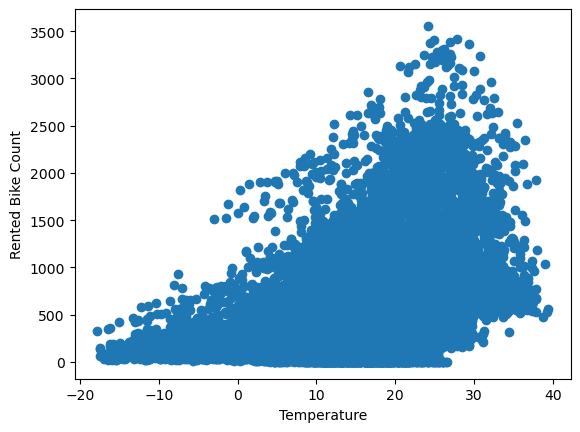

In [3]:
#1
plt.scatter(bike["Temperature"],bike["Rented Bike Count"])
plt.xlabel("Temperature")
plt.ylabel("Rented Bike Count")


#2  
The relationship seems to be weakly positive. There seems to be no strong form that can be easily pointed out, its approximate form is a parabola. There seems to not be a lot of variability, data points are clustered in curve that is skewed left.
#3
I think a straight line model is a reasonable first model, however it is not the best. The scatterplot suggest a more negative parabola relationship as when the temperatures grow very high the count seems to start going down. If a straight line model is used, the decline will be lost and the dense data of below 1000 that seems to be present for all temperatures will not be accurately captured. 


In [5]:
#Part 2
#1
rental_model = LinearRegression()
rental_model.fit(bike[['Temperature']],bike[['Rented Bike Count']])
intercept = rental_model.intercept_
slope = rental_model.coef_[0]
print(f"Beta_0 is {intercept} and beta_1 is {slope}")


Beta_0 is [329.95251395] and beta_1 is [29.08109899]


#2
When the temperature is 0 degree celcius, there are around 329.95 bikes rented during the hours.
#3
For one degree in temperature increase, there are around 29 more bikes rented during the hours.
#4
Using the fitted model, the predcited bike rentals will differy by around 291 bikes. 

In [6]:
10*slope

array([290.81098989])

#Part 3
#1
A residual is the difference between the observed bike counts and the predcited bike counts from the model. A positive residual means that the model underestimated and a negative one means that the model overestimated. 
#2
1) A higher absolute difference are punished more. 
2) The differences don't get cancelled out due to having both positive and negative differences. 
#3
OLS prefers model B because the sum of squared errors are smaller (meaning the model was better at prediciting the data/had less residuals overall).
#4
Not necessarily. If you overfit the data to make the SSE small, the the model would simply be good at predicting the training data rather than new future data.

#Part 4
#1

In [10]:
#2
x=bike["Temperature"]
y=bike["Rented Bike Count"]
n=len(y)
learning_rate=1e-8
b0 = 0.0
b1 = 0.0

iterations = 10000


checkpoints = [
    0,
    1,
    5,
    10,
    25,
    50,
    100,
    250,
    500,
    1000,
    2500,
    5000,
    7500,
    10000
]

history = {
    0: {
        "b0": b0,
        "b1": b1
    }
}

for i in range(1, iterations + 1):

    y_hat = b0 + b1 * x


    residual = y - y_hat


    grad_b0 = -(2 / n) * np.sum(
        residual
    )

    grad_b1 = -(2 / n) * np.sum(
        residual * x
    )


    b0 = b0 - learning_rate * grad_b0

    b1 = b1 - learning_rate * grad_b1

    if i in checkpoints:

        history[i] = {
            "b0": b0,
            "b1": b1
        }

In [11]:
gd_b0 = b0
gd_b1 = b1
results = []

for iteration, values in history.items():

    results.append({

        "iteration": iteration,

        "intercept": values["b0"],

        "slope": values["b1"]
    })

results = pd.DataFrame(results)

results

,iteration,intercept,slope
0,0,0.000000,0.000000
1,1,0.000014,0.000265
2,5,0.000070,0.001323
3,10,0.000141,0.002645
4,25,0.000352,0.006613
5,50,0.000705,0.013224
6,100,0.001409,0.026444
7,250,0.003521,0.066080
8,500,0.007037,0.132057
9,1000,0.014058,0.263707


#3
Final b_0: around 0.14
Final b_1: around 2.57

a bit off, somewhat close

#5 
if learning rate is too large we may miss the minimum and skip it completely 